In [ ]:
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

Shape: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Summary Statistics:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.

In [ ]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop(columns=['Cabin'])

In [ ]:
# Convert 'Sex' column into numerical format
# 'male' is encoded as 0 and 'female' as 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Perform one-hot encoding on 'Embarked' column
# This creates new columns with all flags
df = pd.get_dummies(df, columns=['Embarked'])

In [ ]:
# Drop columns that do not contribute to prediction

# 'Name' → contains text data with no direct predictive value
# 'Ticket' → complex and inconsistent values
# 'PassengerId' → just a unique identifier, not useful for prediction
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

In [ ]:
print(df.isnull().sum())

# Display first 5 rows of cleaned dataset
df.head()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


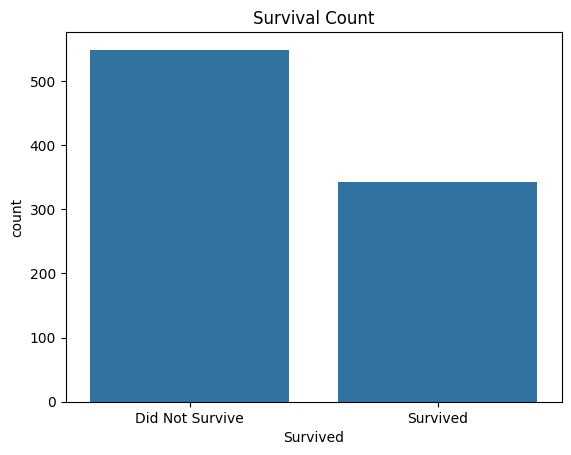

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many people survived and did not survive
sns.countplot(x='Survived', data=df)

# Add title
plt.title("Survival Count")

# Change labels from 0,1 to meaningful text
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# Show graph
plt.show()

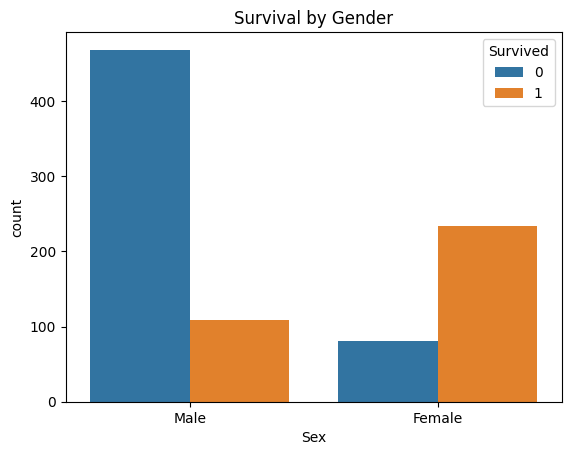

In [ ]:
# Compare survival based on gender
sns.countplot(x='Sex', hue='Survived', data=df)

# Add title
plt.title("Survival by Gender")

# Change labels (0 = Male, 1 = Female)
plt.xticks([0, 1], ['Male', 'Female'])

# Show graph
plt.show()

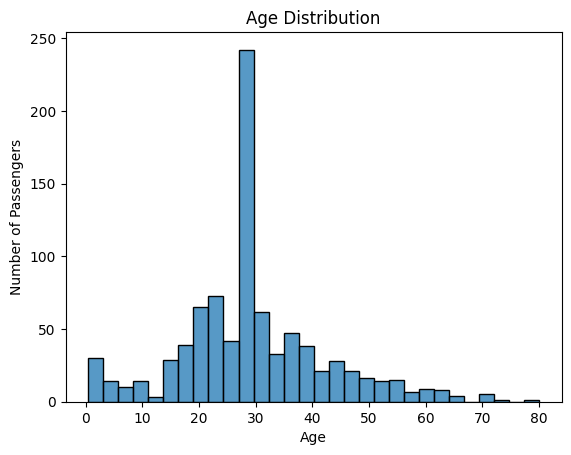

In [ ]:
# Show how ages are distributed
sns.histplot(df['Age'], bins=30)

# Add title
plt.title("Age Distribution")

# Label axes
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

# Show graph
plt.show()

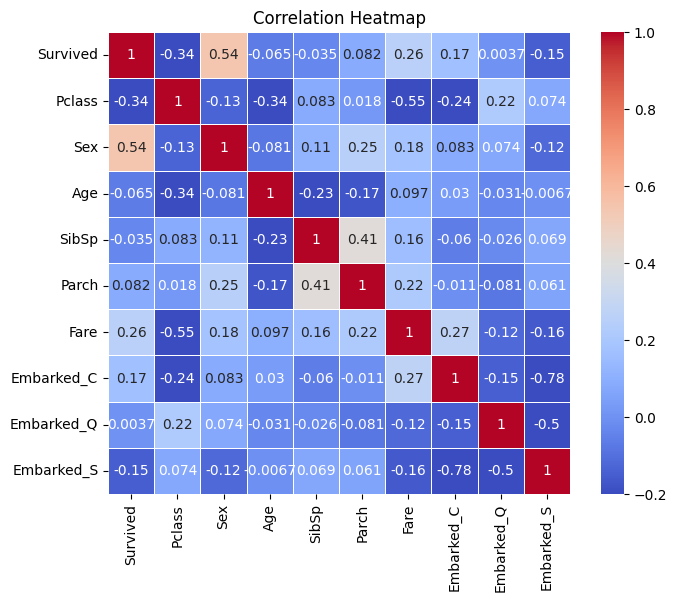

In [ ]:
# Find correlation between all columns
corr = df.corr()
plt.figure(figsize=(8, 6))
# Show heatmap
sns.heatmap(corr, annot=True,cmap="coolwarm",vmin=-0.2,square=True,linewidths=0.5)

# Title
plt.title("Correlation Heatmap")

# Show graph
plt.show()

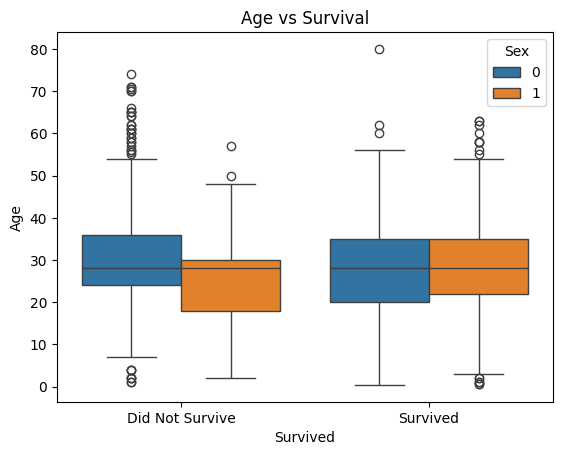

In [ ]:
# Compare age with survival
sns.boxplot(x='Survived', y='Age',hue='Sex', data=df,palette="tab10")

# Title
plt.title("Age vs Survival")

# Change labels
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# Show graph
plt.show()

In [ ]:
# Target variable (what we want to predict)
y = df['Survived']

# Features (all input columns except target)
X = df.drop(columns=['Survived'])

In [ ]:
from sklearn.model_selection import train_test_split  # Import function to split data

# Split dataset into training and testing sets
# X → input features, y → target variable
# test_size=0.2 means 20% data is used for testing
# random_state=42 ensures same result every time you run

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression  # Import model

# Create Logistic Regression model
# max_iter=1000 increases number of iterations for better convergence
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score  # Import accuracy metric

# Predict results on test data
y_pred = model.predict(X_test)

# Calculate accuracy (correct predictions / total predictions)
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [ ]:
from sklearn.metrics import confusion_matrix  # Import confusion matrix
# What is Confusion Matrix?
# a table used to evaluate the performance of a classification model.
# It shows how many predictions are correct and incorrect.

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print matrix
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[90 15]
 [19 55]]


In [ ]:
# Extract values for better understanding
TN, FP, FN, TP = cm.ravel()

print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives:", TP)

# TN (True Negative):
# Correctly predicted passengers who did NOT survive

# FP (False Positive):
# Predicted survived, but actually did NOT survive

# FN (False Negative):
# Predicted not survived, but actually survived

# TP (True Positive):
# Correctly predicted passengers who survived

True Negatives: 90
False Positives: 15
False Negatives: 19
True Positives: 55


In [ ]:
# Overall Model Performance:
# The model gives good accuracy (around 80%).
# This means most predictions are correct.
# The model is working well for this dataset.


# Types of Errors:
# The model makes some mistakes:
# False Positive → predicted survived but actually did not survive
# False Negative → predicted not survived but actually survived


# Reasons for Errors:
# Some passengers have similar data but different outcomes
# Some data was missing (like Cabin), so we removed it
# The dataset does not include all real-life factors


# Limitations:
# The dataset is small
# The model used is simple (Logistic Regression)
# Not all useful features are available


# Improvements:
# Use better models like Decision Tree or Random Forest
# Add new features (like family size)
# Try improving data preprocessing